**Game Recommender System ด้วย Graph**

In [ ]:
!pip -q install networkx

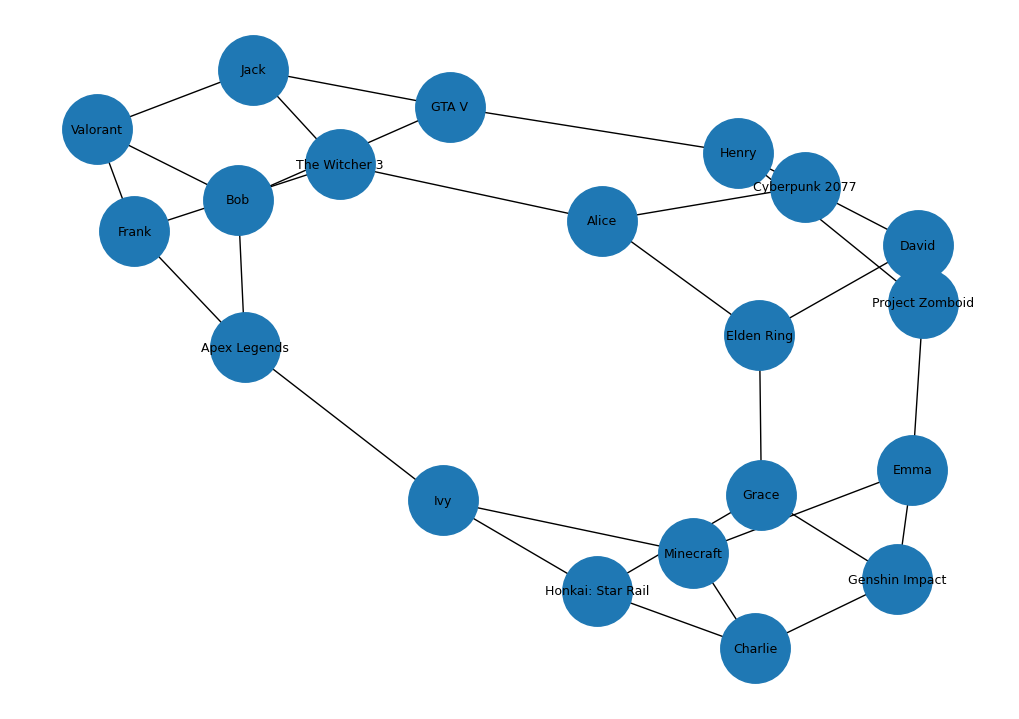

Recommendations for Jack
Apex Legends Score = 4
Cyberpunk 2077 Score = 2
Elden Ring Score = 1
Project Zomboid Score = 1


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

from collections import Counter


# ==================================
# 1. Create Graph
# ==================================

G = nx.Graph()


# ==================================
# 2. Add Users
# ==================================

users = [
    "Alice",
    "Bob",
    "Charlie",
    "David",
    "Emma",
    "Frank",
    "Grace",
    "Henry",
    "Ivy",
    "Jack",
]

for user in users:

    G.add_node(
        user,
        node_type="user"
    )


# ==================================
# 3. Add Game
# ==================================

games = [
    "Elden Ring",
    "Cyberpunk 2077",
    "Minecraft",
    "Valorant",
    "Genshin Impact",
    "Honkai: Star Rail",
    "The Witcher 3",
    "GTA V",
    "Apex Legends",
    "Project Zomboid",
]

for game in games:

    G.add_node(
        game,
        node_type="game"
    )


# ==================================
# 4. User-Game Relationships
# ==================================

likes = [
    ("Alice", "Elden Ring"),
    ("Alice", "The Witcher 3"),
    ("Alice", "Cyberpunk 2077"),
    ("Bob", "Valorant"),
    ("Bob", "Apex Legends"),
    ("Bob", "GTA V"),
    ("Charlie", "Genshin Impact"),
    ("Charlie", "Honkai: Star Rail"),
    ("Charlie", "Minecraft"),
    ("David", "Elden Ring"),
    ("David", "Project Zomboid"),
    ("David", "Cyberpunk 2077"),
    ("Emma", "Minecraft"),
    ("Emma", "Project Zomboid"),
    ("Emma", "Genshin Impact"),
    ("Frank", "Valorant"),
    ("Frank", "Apex Legends"),
    ("Frank", "The Witcher 3"),
    ("Grace", "Honkai: Star Rail"),
    ("Grace", "Genshin Impact"),
    ("Grace", "Elden Ring"),
    ("Henry", "GTA V"),
    ("Henry", "Cyberpunk 2077"),
    ("Henry", "Project Zomboid"),
    ("Ivy", "Minecraft"),
    ("Ivy", "Honkai: Star Rail"),
    ("Ivy", "Apex Legends"),
    ("Jack", "GTA V"),
    ("Jack", "Valorant"),
    ("Jack", "The Witcher 3"),
]


G.add_edges_from(likes)


# ==================================
# 5. Draw Graph
# ==================================

plt.figure(
    figsize=(10, 7)
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)


plt.show()


# ==================================
# 6. Recommendation Function
# ==================================

def recommend_games(G, target_user):

    recommendations = Counter()

    liked_games = set(
        G.neighbors(
            target_user
        )
    )

    for game in liked_games:

        for similar_user in G.neighbors(game):

            if similar_user == target_user:
                continue

            for other_game in G.neighbors(
                similar_user
            ):

                if other_game not in liked_games:

                    recommendations[
                        other_game
                    ] += 1

    return recommendations.most_common()


# ==================================
# 7. Recommend for username
# ==================================

target_user = "Jack"

result = recommend_games(
    G,
    target_user
)


print(
    "Recommendations for",
    target_user
)


for game, score in result:

    print(
        game,
        "Score =",
        score
    )